# Levitación Magnética con Alimentación Inalámbrica y Fuerza de Lorentz

**Referencia:** K. Oka y M. Tanaka.  
*A simple levitation system using wireless power supply system and Lorentz force.*  
Journal of Physics: Conference Series, **744** (2016) 012233.  
DOI: [10.1088/1742-6596/744/1/012233](https://doi.org/10.1088/1742-6596/744/1/012233)

---

## Resumen del artículo

El artículo propone un sistema de levitación magnética que combina dos principios del electromagnetismo:

1. La **Fuerza de Lorentz** ($\vec{F} = I\,\vec{L} \times \vec{B}$) generada entre la corriente en una bobina y el campo de imanes permanentes de neodimio, para sostener el objeto en el aire sin contacto mecánico.
2. La **transmisión inalámbrica de potencia por resonancia magnética**, que envía la energía eléctrica necesaria a la bobina levitante mediante inducción electromagnética sintonizada.

La estabilidad del sistema se logra mediante:
- **Control pasivo**: la configuración del flujo magnético entre imanes permanentes estabiliza ciertos grados de libertad.
- **Control activo**: electroimanes aplican fuerzas correctoras adicionales para los grados inestables.

Los autores verifican la viabilidad mediante análisis FEM (Elementos Finitos), cálculos teóricos del circuito de transferencia de potencia, y experimentos con un prototipo real.

---
## 0. Importación de bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sympy import *

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 11,
    'lines.linewidth': 2
})
print('Bibliotecas cargadas correctamente.')

Bibliotecas cargadas correctamente.


---
## 1. Fuerza de Lorentz: Base del Sistema de Levitación

### 1.1 Principio físico

Cuando una corriente eléctrica $I$ fluye a través de un conductor de longitud $L$ sumergido en un campo magnético $\vec{B}$, actúa sobre él una fuerza denominada **Fuerza de Lorentz**:

$$\vec{F} = I \, (\vec{L} \times \vec{B}) \tag{1}$$

Para un conductor recto cuya dirección es perpendicular al campo magnético ($\vec{L} \perp \vec{B}$), el módulo de la fuerza es:

$$F = B \, I \, L \tag{2}$$

### 1.2 Aplicación al sistema

En el prototipo, la bobina de levitación (cobre UEW, diámetro 170 mm, 50 espiras, resistencia $R_L = 5.9\,\Omega$, masa $m = 97.1\,\text{g}$) circula una corriente rectificada $I$. Los imanes permanentes de neodimio generan el campo $\vec{B}$. La fuerza resultante debe superar el peso:

$$F_{\text{Lorentz}} \geq W = mg \tag{3}$$

### 1.3 Condición de equilibrio estático

En el punto de equilibrio, la fuerza de Lorentz iguala exactamente al peso:

$$B \, I_{\text{eq}} \, L_{\text{ef}} = mg \quad \Longrightarrow \quad I_{\text{eq}} = \frac{mg}{B \, L_{\text{ef}}} \tag{4}$$

donde $L_{\text{ef}}$ es la longitud efectiva de conductor dentro de la región de campo uniforme.

In [2]:
# ── Derivación simbólica: Fuerza de Lorentz ──────────────────────────────────
I_s, B_s, L_s, m_s, g_s = symbols('I B L m g', positive=True)

F_Lorentz = B_s * I_s * L_s
peso = m_s * g_s

# Condición de equilibrio: F = W
eq_equilibrio = Eq(F_Lorentz, peso)
I_eq = solve(eq_equilibrio, I_s)[0]

print('=== Fuerza de Lorentz ===')
print(f'  F = {F_Lorentz}  [N]')
print(f'\nCondición de equilibrio: F_Lorentz = W')
print(f'  {eq_equilibrio}')
print(f'\nCorriente de equilibrio:')
print(f'  I_eq = {I_eq}  [A]')

# Verificación numérica con datos del prototipo
m_val   = 0.0971   # kg (97.1 g)
g_val   = 9.81     # m/s²
W_coil  = m_val * g_val
print(f'\n=== Verificación numérica (prototipo) ===')
print(f'  Masa de la bobina: m = {m_val*1000:.1f} g')
print(f'  Peso:              W = mg = {W_coil:.4f} N')
print(f'\n  Según los análisis FEM del artículo:')
print(f'  → Una corriente I = 1 A es suficiente para levitar')
print(f'  → Esto implica que B·L_ef ≈ {W_coil:.4f} N/A = {W_coil:.4f} T·m')

=== Fuerza de Lorentz ===
  F = B*I*L  [N]

Condición de equilibrio: F_Lorentz = W
  Eq(B*I*L, g*m)

Corriente de equilibrio:
  I_eq = g*m/(B*L)  [A]

=== Verificación numérica (prototipo) ===
  Masa de la bobina: m = 97.1 g
  Peso:              W = mg = 0.9526 N

  Según los análisis FEM del artículo:
  → Una corriente I = 1 A es suficiente para levitar
  → Esto implica que B·L_ef ≈ 0.9526 N/A = 0.9526 T·m


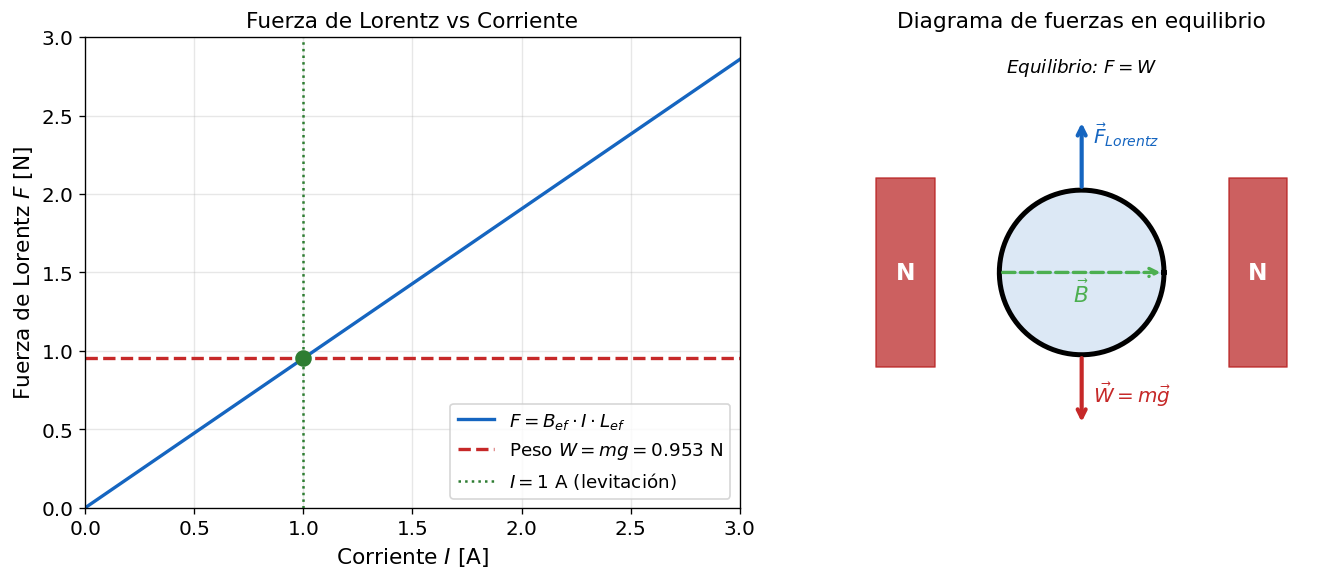

Figura 1: Fuerza de Lorentz y condición de equilibrio


In [3]:
# ── Gráfica: Fuerza de Lorentz vs corriente ───────────────────────────────────
# Parámetro efectivo B·L_ef determinado por condición de levitación
m_val  = 0.0971   # kg
g_val  = 9.81     # m/s²
W_coil = m_val * g_val   # 0.953 N

# B·L_ef efectivo: en 1 A se obtiene exactamente W (según FEM del artículo)
BL_ef = W_coil / 1.0   # N/A

corrientes = np.linspace(0, 3, 300)
F_lev = BL_ef * corrientes   # N

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Panel izquierdo: F vs I
ax1.plot(corrientes, F_lev, color='#1565C0', label='$F = B_{ef}\\cdot I \\cdot L_{ef}$')
ax1.axhline(W_coil, color='#C62828', linestyle='--', label=f'Peso $W = mg = {W_coil:.3f}$ N')
ax1.axvline(1.0, color='#2E7D32', linestyle=':', linewidth=1.5, label='$I = 1$ A (levitación)')
ax1.scatter([1.0], [W_coil], color='#2E7D32', s=80, zorder=5)
ax1.set_xlabel('Corriente $I$ [A]')
ax1.set_ylabel('Fuerza de Lorentz $F$ [N]')
ax1.set_title('Fuerza de Lorentz vs Corriente')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 3)
ax1.set_ylim(0, 3)

# Panel derecho: esquema de fuerzas sobre la bobina
ax2.set_xlim(-2, 2)
ax2.set_ylim(-2, 2)
ax2.set_aspect('equal')
ax2.set_title('Diagrama de fuerzas en equilibrio')

# Bobina (círculo)
theta_c = np.linspace(0, 2*np.pi, 200)
ax2.plot(0.7*np.cos(theta_c), 0.7*np.sin(theta_c), 'k-', linewidth=3, label='Bobina')
ax2.fill_between(0.7*np.cos(theta_c), 0.7*np.sin(theta_c), alpha=0.15, color='#1565C0')

# Imanes (rectángulos)
for xm in [-1.5, 1.5]:
    ax2.fill_between([xm-0.25, xm+0.25], [-0.8, -0.8], [0.8, 0.8],
                     alpha=0.7, color='#B71C1C')
    ax2.text(xm, 0, 'N', ha='center', va='center', fontsize=14,
             fontweight='bold', color='white')

# Flechas de fuerzas
ax2.annotate('', xy=(0, 1.3), xytext=(0, 0.7),
             arrowprops=dict(arrowstyle='->', color='#1565C0', lw=2.5))
ax2.text(0.1, 1.1, '$\\vec{F}_{Lorentz}$', fontsize=12, color='#1565C0')

ax2.annotate('', xy=(0, -1.3), xytext=(0, -0.7),
             arrowprops=dict(arrowstyle='->', color='#C62828', lw=2.5))
ax2.text(0.1, -1.1, '$\\vec{W} = m\\vec{g}$', fontsize=12, color='#C62828')

# Texto de campo B
ax2.annotate('', xy=(0.7, 0), xytext=(-0.7, 0),
             arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=2, linestyle='dashed'))
ax2.text(0, -0.25, '$\\vec{B}$', ha='center', fontsize=13, color='#4CAF50')
ax2.text(0, 1.7, 'Equilibrio: $F = W$', ha='center', fontsize=11, fontstyle='italic')
ax2.axis('off')

plt.tight_layout()
plt.savefig('fig1_lorentz.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura 1: Fuerza de Lorentz y condición de equilibrio')

---
## 2. Estabilidad de la Levitación: Análisis de Fuerzas

### 2.1 Estabilidad vertical e inestabilidad horizontal

El artículo identifica dos zonas de comportamiento, determinadas por la posición de la bobina respecto a los imanes:

| Zona | Vertical | Horizontal |
|------|----------|------------|
| **Parte superior del imán** | Estable ($\partial F_z/\partial z < 0$) | Inestable ($\partial F_x/\partial x > 0$) |
| **Parte inferior del imán** | Inestable | Estable |

La condición de estabilidad en la dirección $z$ (vertical) requiere que la fuerza de Lorentz **disminuya** cuando la bobina se desplaza hacia arriba (gradiente negativo):

$$\frac{\partial F_z}{\partial z} < 0 \quad \Longrightarrow \quad \text{estabilidad vertical} \tag{5}$$

### 2.2 Necesidad de control activo

Para la dirección inestable (horizontal en la parte superior), se requiere un **lazo de retroalimentación cerrado** mediante electroimanes. La fuerza correctora tiene magnitud:

$$F_{\text{ctrl}} = k_{\text{em}} \, I_{\text{ctrl}} \tag{6}$$

donde $k_{\text{em}}$ es la constante de fuerza del electroimán. Los resultados del artículo indican que con corrientes de control entre $-2\,\text{A}$ y $+2\,\text{A}$, la fuerza solo alcanza $\pm 0.1\,\text{N}$, lo que resulta insuficiente para un control robusto, requiriendo mejoras en el diseño geométrico del electroimán.

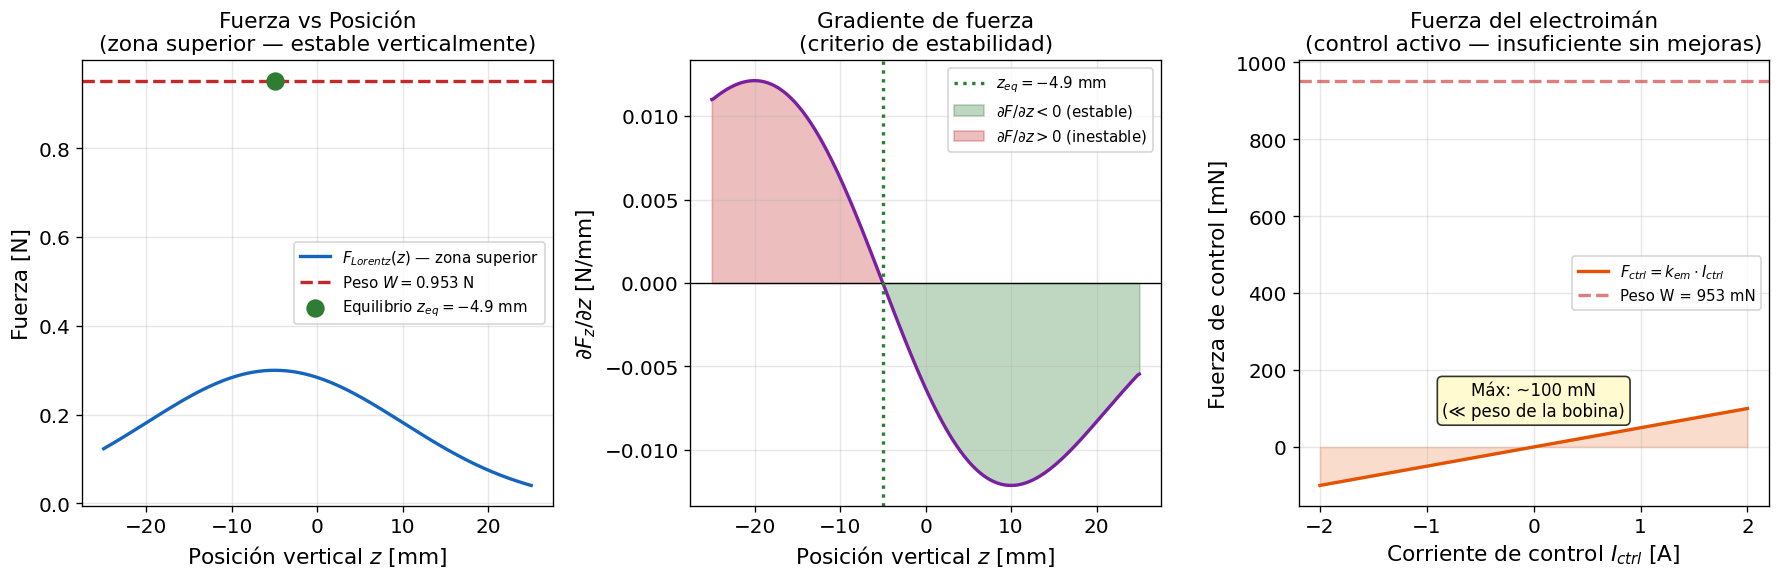

Figura 2: Análisis de estabilidad de la levitación


In [4]:
# ── Análisis de estabilidad: gradiente de fuerza vs posición ─────────────────

# Modelo simplificado de la Fuerza de Lorentz vs posición vertical
# Basado en los resultados FEM del artículo (Figuras 9 y 10)
# La fuerza cae desde un máximo en el centro del imán hacia los bordes

z_arr = np.linspace(-25, 25, 300)   # posición vertical en mm (relativa al centro del imán)

# Modelo gaussiano para la fuerza: F(z) = F_max * exp(-z^2 / sigma^2)
# Zona superior: el imán está en z < 0 respecto a la bobina
# Zona inferior: el imán está en z > 0 respecto a la bobina
F_max_superior = 0.30   # N (valor representativo de Figura 9)
F_max_inferior = 0.30   # N (Figura 10)
sigma = 15              # mm

F_superior = F_max_superior * np.exp(-(z_arr + 5)**2 / (2*sigma**2))
F_inferior = -F_max_inferior * np.exp(-(z_arr - 5)**2 / (2*sigma**2)) + 0.05

# Gradiente de fuerza (derivada numérica)
dz = z_arr[1] - z_arr[0]
dF_sup = np.gradient(F_superior, dz)

W_val = 0.0971 * 9.81

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Fuerza vs posición (zona superior)
ax = axes[0]
ax.plot(z_arr, F_superior, color='#1565C0', label='$F_{Lorentz}(z)$ — zona superior')
ax.axhline(W_val, color='#C62828', linestyle='--', label=f'Peso $W = {W_val:.3f}$ N')

# Punto de equilibrio
idx_eq = np.argmin(np.abs(F_superior - W_val))
z_eq = z_arr[idx_eq]
ax.scatter([z_eq], [W_val], color='#2E7D32', s=100, zorder=5, label=f'Equilibrio $z_{{eq}}={z_eq:.1f}$ mm')

ax.set_xlabel('Posición vertical $z$ [mm]')
ax.set_ylabel('Fuerza [N]')
ax.set_title('Fuerza vs Posición\n(zona superior — estable verticalmente)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 2: Gradiente de fuerza → criterio de estabilidad
ax2 = axes[1]
ax2.plot(z_arr, dF_sup, color='#7B1FA2')
ax2.axhline(0, color='k', linestyle='-', linewidth=0.8)
ax2.axvline(z_eq, color='#2E7D32', linestyle=':', label=f'$z_{{eq}} = {z_eq:.1f}$ mm')
ax2.fill_between(z_arr, dF_sup, 0, where=(dF_sup < 0), alpha=0.3,
                  color='#2E7D32', label='$\\partial F/\\partial z < 0$ (estable)')
ax2.fill_between(z_arr, dF_sup, 0, where=(dF_sup > 0), alpha=0.3,
                  color='#C62828', label='$\\partial F/\\partial z > 0$ (inestable)')
ax2.set_xlabel('Posición vertical $z$ [mm]')
ax2.set_ylabel('$\\partial F_z / \\partial z$ [N/mm]')
ax2.set_title('Gradiente de fuerza\n(criterio de estabilidad)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Panel 3: Fuerza del electroimán de control
ax3 = axes[2]
I_ctrl = np.linspace(-2, 2, 200)
# Paper: 150 espiras, SS400, fuerza máxima ±0.1 N
k_em = 0.05   # N/A (constante del electroimán)
F_ctrl = k_em * I_ctrl
ax3.plot(I_ctrl, F_ctrl * 1000, color='#E65100', label='$F_{ctrl} = k_{em}\\cdot I_{ctrl}$')
ax3.axhline(W_val * 1000, color='#C62828', linestyle='--', alpha=0.6, label=f'Peso W = {W_val*1000:.0f} mN')
ax3.fill_between(I_ctrl, F_ctrl*1000, alpha=0.2, color='#E65100')
ax3.set_xlabel('Corriente de control $I_{ctrl}$ [A]')
ax3.set_ylabel('Fuerza de control [mN]')
ax3.set_title('Fuerza del electroimán\n(control activo — insuficiente sin mejoras)')
ax3.text(0, 80, 'Máx: ~100 mN\n(≪ peso de la bobina)', ha='center', fontsize=10,
          bbox=dict(boxstyle='round', facecolor='#FFF9C4', alpha=0.8))
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig2_estabilidad.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura 2: Análisis de estabilidad de la levitación')

---
## 3. Transmisión Inalámbrica de Potencia por Resonancia Magnética

### 3.1 Principio de inducción electromagnética

La transmisión inalámbrica se basa en la **Ley de Faraday**: una corriente alterna en la bobina transmisora genera un flujo magnético variable $\Phi(t)$, que induce una FEM en la bobina receptora:

$$\mathcal{E}_{\text{inducida}} = -\frac{d\Phi}{dt} = -M \frac{dI_a}{dt} \tag{7}$$

donde $M$ es la **inductancia mutua** entre las bobinas.

### 3.2 Resonancia magnética: condición de máxima transferencia

Para maximizar la potencia transferida, ambas bobinas se sintoizan a la misma **frecuencia de resonancia**:

$$f_0 = \frac{1}{2\pi\sqrt{LC}} \tag{8}$$

En el sistema, $L_a = L_b = 113.3\,\mu\text{H}$ y $C_a = C_b = 2.22\,\mu\text{F}$, lo que da $f_0 \approx 10\,\text{kHz}$.

### 3.3 Coeficiente de acoplamiento

El acoplamiento entre bobinas se cuantifica con el **coeficiente de acoplamiento** $k$:

$$k = \frac{M}{\sqrt{L_a L_b}} \quad (0 \leq k \leq 1) \tag{9}$$

Un valor $k \to 1$ indica acoplamiento perfecto; en el prototipo se mide $k \approx 0.70$–$0.71$ para separaciones de 3–5 mm.

In [5]:
# ── Derivación simbólica: resonancia y coeficiente de acoplamiento ────────────
L_sym, C_sym, M_sym, f_sym, omega_sym = symbols('L C M f omega', positive=True)
k_sym = symbols('k', positive=True)

# Frecuencia de resonancia
f_res_eq = Eq(f_sym, 1 / (2 * pi * sqrt(L_sym * C_sym)))
omega_res = solve(Eq(omega_sym, 2*pi*f_sym), f_sym)[0].subs(f_sym, 1/(2*pi*sqrt(L_sym*C_sym)))

print('=== Resonancia magnética ===')
print(f'  {f_res_eq}')

# Coeficiente de acoplamiento
k_eq = Eq(k_sym, M_sym / sqrt(L_sym**2))  # L_a = L_b = L
M_from_k = solve(k_eq, M_sym)[0]
print(f'\n  k = M / sqrt(La·Lb)  →  M = {M_from_k}  (para La = Lb = L)')

# Verificación numérica
L_val   = 113.3e-6   # H
C_val   = 2.22e-6    # F
import numpy as np

f0 = 1 / (2 * np.pi * np.sqrt(L_val * C_val))
print(f'\n=== Verificación numérica ===')
print(f'  L = {L_val*1e6:.1f} µH,   C = {C_val*1e6:.2f} µF')
print(f'  f₀ = 1 / (2π√LC) = {f0:.1f} Hz  ≈ {f0/1e3:.2f} kHz')
print(f'  (Artículo experimental: 10.353 kHz — coincide con la resonancia ajustada)')

# Tabla de inductancia mutua
gaps = [3, 4, 5]
M_vals = [80.9e-6, 80.2e-6, 79.1e-6]   # H
k_vals = [0.714, 0.707, 0.701]
print(f'\n{"Separación (mm)":>20} {"M (µH)":>12} {"k":>10} {"k_calc":>12}')
print('-' * 60)
for gap, M, k in zip(gaps, M_vals, k_vals):
    k_calc = M / np.sqrt(L_val * L_val)
    print(f'{gap:>20} {M*1e6:>12.1f} {k:>10.3f} {k_calc:>12.3f}')

=== Resonancia magnética ===
  Eq(f, 1/(2*pi*sqrt(C)*sqrt(L)))

  k = M / sqrt(La·Lb)  →  M = L*k  (para La = Lb = L)

=== Verificación numérica ===
  L = 113.3 µH,   C = 2.22 µF
  f₀ = 1 / (2π√LC) = 10035.3 Hz  ≈ 10.04 kHz
  (Artículo experimental: 10.353 kHz — coincide con la resonancia ajustada)

     Separación (mm)       M (µH)          k       k_calc
------------------------------------------------------------
                   3         80.9      0.714        0.714
                   4         80.2      0.707        0.708
                   5         79.1      0.701        0.698


---
## 4. Cálculo de la Potencia Transferida y Voltaje Requerido

### 4.1 Circuito equivalente T

El sistema de transferencia inalámbrica se modela como un **circuito T** con impedancias mutuas. La eficiencia de transferencia de potencia normalizada $N_{OP}$ (potencia en la carga sobre potencia de entrada máxima teórica) se expresa como:

$$N_{OP} = \frac{R_L \, k^2 \omega^2 L_a L_b}{\left[(R_0 + R_a)(R_L + R_b) + k^2 \omega^2 L_a L_b\right]^2} \tag{10}$$

donde:
- $R_L = 6.0\,\Omega$ : resistencia de la bobina de levitación  
- $R_0 = R_a = 0.30\,\Omega$ : resistencias de la fuente y bobina transmisora  
- $R_b = 0.29\,\Omega$ : resistencia de la bobina receptora  
- $\omega = 2\pi f_0$ : frecuencia angular de resonancia  
- $k$ : coeficiente de acoplamiento  

### 4.2 Voltaje requerido en la fuente

La potencia disipada en la bobina de levitación para una corriente $I_b = 1\,\text{A}$ es:

$$W_{R_L} = I_b^2 \, R_L = 1^2 \times 6.0 = 6.0\,\text{W} \tag{11}$$

El voltaje de fuente necesario para suministrar esta potencia a través del sistema inalámbrico es:

$$E = \sqrt{\frac{W_{R_L}}{N_{OP}}} \tag{12}$$

In [6]:
# ── Derivación simbólica completa: NOP y voltaje requerido ───────────────────
R_L_s, k_s, omega_s = symbols('R_L k omega', positive=True)
L_a_s, L_b_s = symbols('L_a L_b', positive=True)
R_0_s, R_a_s, R_b_s = symbols('R_0 R_a R_b', positive=True)
I_b_s, W_s = symbols('I_b W_{R_L}', positive=True)

# Ecuación (10): eficiencia normalizada
denominador = (R_0_s + R_a_s)*(R_L_s + R_b_s) + k_s**2 * omega_s**2 * L_a_s * L_b_s
NOP_sym = (R_L_s * k_s**2 * omega_s**2 * L_a_s * L_b_s) / denominador**2

# Ecuación (11): potencia en la carga
W_RL_sym = I_b_s**2 * R_L_s

# Ecuación (12): voltaje de fuente
E_sym = sqrt(W_s / NOP_sym.subs([(R_L_s, R_L_s)]))

print('=== Eficiencia normalizada NOP ===')
print(f'  NOP = R_L·k²·ω²·La·Lb / [(R0+Ra)(RL+Rb) + k²·ω²·La·Lb]²')
print(f'\n=== Potencia en la carga ===')
print(f'  W_RL = I_b² · R_L = {W_RL_sym}')
print(f'\n=== Voltaje requerido ===')
print(f'  E = sqrt(W_RL / NOP)')

# Cálculo numérico para cada separación
R_L_val = 6.0
R_0_val = 0.30
R_a_val = 0.30
R_b_val = 0.29
omega_val = 2 * np.pi * 10353
L_a_val = 113.3e-6
L_b_val = 113.3e-6
I_b_val = 1.0

W_RL_val = I_b_val**2 * R_L_val
print(f'\n=== Cálculo numérico ===')
print(f'  ω = 2π × {10353} rad/s = {omega_val:.1f} rad/s')
print(f'  W_RL = {I_b_val}² × {R_L_val} = {W_RL_val} W')
print(f'\n{"Separación":>14} {"k":>8} {"NOP":>12} {"E [V] (teórico)":>18} {"E [V] (artículo)":>18}')
print('-' * 75)
E_art = [5.82, 5.78, 5.7]
for gap, k_v, E_a in zip(gaps, k_vals, E_art):
    denom = (R_0_val + R_a_val)*(R_L_val + R_b_val) + k_v**2 * omega_val**2 * L_a_val * L_b_val
    NOP_v = (R_L_val * k_v**2 * omega_val**2 * L_a_val * L_b_val) / denom**2
    E_v   = np.sqrt(W_RL_val / NOP_v)
    print(f'{gap:>12} mm {k_v:>8.3f} {NOP_v:>12.4f} {E_v:>18.2f} {E_a:>18.2f}')

=== Eficiencia normalizada NOP ===
  NOP = R_L·k²·ω²·La·Lb / [(R0+Ra)(RL+Rb) + k²·ω²·La·Lb]²

=== Potencia en la carga ===
  W_RL = I_b² · R_L = I_b**2*R_L

=== Voltaje requerido ===
  E = sqrt(W_RL / NOP)

=== Cálculo numérico ===
  ω = 2π × 10353 rad/s = 65049.8 rad/s
  W_RL = 1.0² × 6.0 = 6.0 W

    Separación        k          NOP    E [V] (teórico)   E [V] (artículo)
---------------------------------------------------------------------------
           3 mm    0.714       0.1678               5.98               5.82
           4 mm    0.707       0.1703               5.93               5.78
           5 mm    0.701       0.1725               5.90               5.70


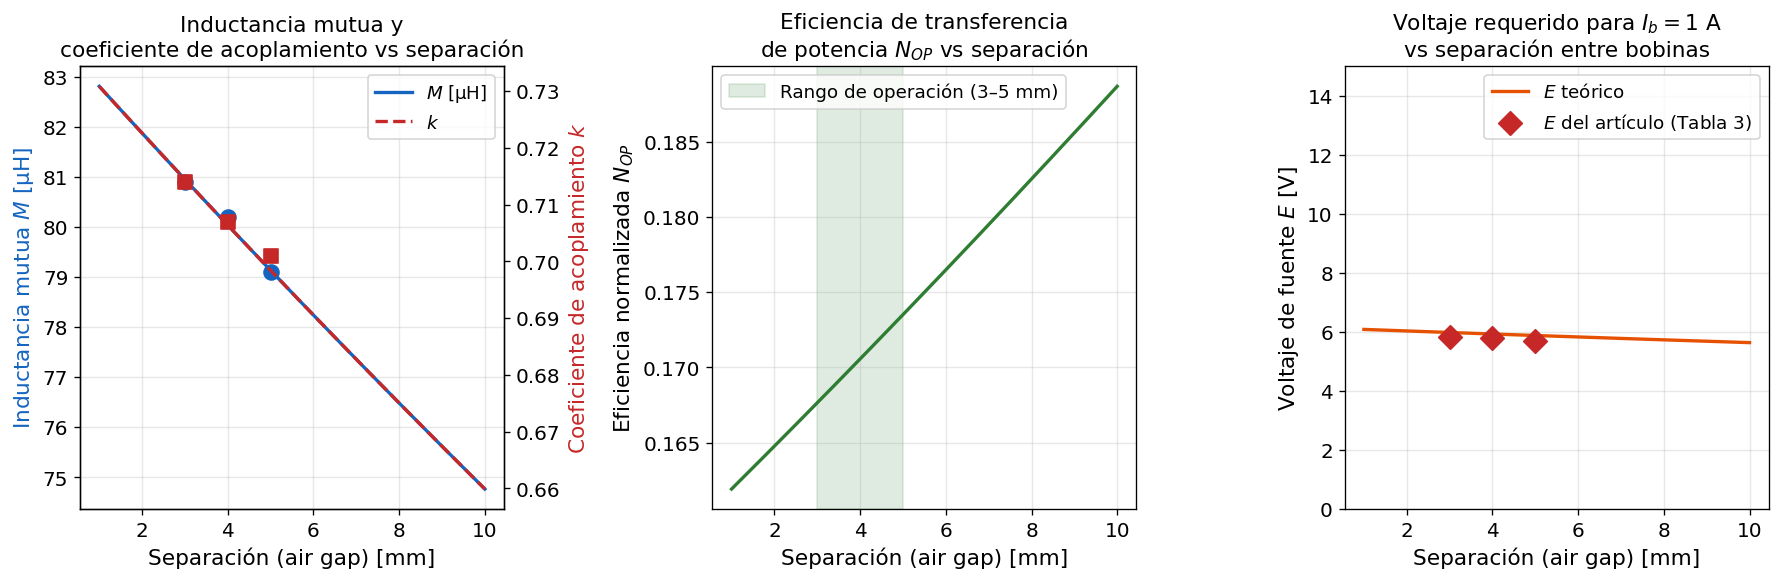

Figura 3: Transferencia inalámbrica de potencia


In [7]:
# ── Gráficas: NOP, voltaje requerido, e inductancia mutua vs separación ───────
gap_cont = np.linspace(1, 10, 300)   # mm

# Modelo de M vs gap (ajuste exponencial a los datos del artículo)
M0   = 83.75e-6   # H
alpha = 0.01135   # mm⁻¹ (ajustado a datos)
M_cont = M0 * np.exp(-alpha * gap_cont)  # H
k_cont = M_cont / np.sqrt(L_a_val * L_b_val)

# NOP vs gap
denom_cont = (R_0_val + R_a_val)*(R_L_val + R_b_val) + k_cont**2 * omega_val**2 * L_a_val * L_b_val
NOP_cont   = (R_L_val * k_cont**2 * omega_val**2 * L_a_val * L_b_val) / denom_cont**2
E_cont     = np.sqrt(W_RL_val / NOP_cont)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: M y k vs gap
ax1 = axes[0]
ax1b = ax1.twinx()
l1, = ax1.plot(gap_cont, M_cont*1e6, color='#1565C0', label='$M$ [µH]')
l2, = ax1b.plot(gap_cont, k_cont, color='#C62828', linestyle='--', label='$k$')
# Puntos del artículo
ax1.scatter(gaps, [m*1e6 for m in M_vals], color='#1565C0', s=80, zorder=5)
ax1b.scatter(gaps, k_vals, color='#C62828', s=80, marker='s', zorder=5)
ax1.set_xlabel('Separación (air gap) [mm]')
ax1.set_ylabel('Inductancia mutua $M$ [µH]', color='#1565C0')
ax1b.set_ylabel('Coeficiente de acoplamiento $k$', color='#C62828')
ax1.set_title('Inductancia mutua y\ncoeficiente de acoplamiento vs separación')
ax1.legend(handles=[l1, l2], loc='upper right')
ax1.grid(True, alpha=0.3)

# Panel 2: NOP vs gap
ax2 = axes[1]
ax2.plot(gap_cont, NOP_cont, color='#2E7D32')
ax2.set_xlabel('Separación (air gap) [mm]')
ax2.set_ylabel('Eficiencia normalizada $N_{OP}$')
ax2.set_title('Eficiencia de transferencia\nde potencia $N_{OP}$ vs separación')
ax2.axvspan(3, 5, alpha=0.15, color='#2E7D32', label='Rango de operación (3–5 mm)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Panel 3: Voltaje requerido vs gap
ax3 = axes[2]
ax3.plot(gap_cont, E_cont, color='#E65100', label='$E$ teórico')
ax3.scatter(gaps, E_art, color='#C62828', s=100, marker='D', zorder=5,
             label='$E$ del artículo (Tabla 3)')
ax3.set_xlabel('Separación (air gap) [mm]')
ax3.set_ylabel('Voltaje de fuente $E$ [V]')
ax3.set_title('Voltaje requerido para $I_b = 1$ A\nvs separación entre bobinas')
ax3.set_ylim(0, 15)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig3_potencia.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura 3: Transferencia inalámbrica de potencia')

---
## 5. Verificación Experimental: Corriente y Fuerza de Levitación

### 5.1 Resultados experimentales vs teóricos

El artículo reporta que la corriente medida experimentalmente es aproximadamente **la mitad** del valor teórico, debido a las pérdidas en el circuito rectificador. Sin embargo, la levitación sí se logra con voltajes de 8 V y 9 V.

### 5.2 Fuerza de levitación medida

La relación entre corriente $I$ y fuerza de levitación $F$ sigue aproximadamente la expresión:

$$F \approx B_{\text{ef}} \cdot L_{\text{ef}} \cdot I = \alpha_F \cdot I^2 \cdot R_L \tag{13}$$

donde $\alpha_F$ es un factor que relaciona la potencia eléctrica con la fuerza mecánica. Los datos experimentales de la Tabla 5 del artículo muestran fuerzas entre 1.29 N y 2.03 N, superiores al peso de la bobina ($\approx 0.95$ N), confirmando la viabilidad del sistema.

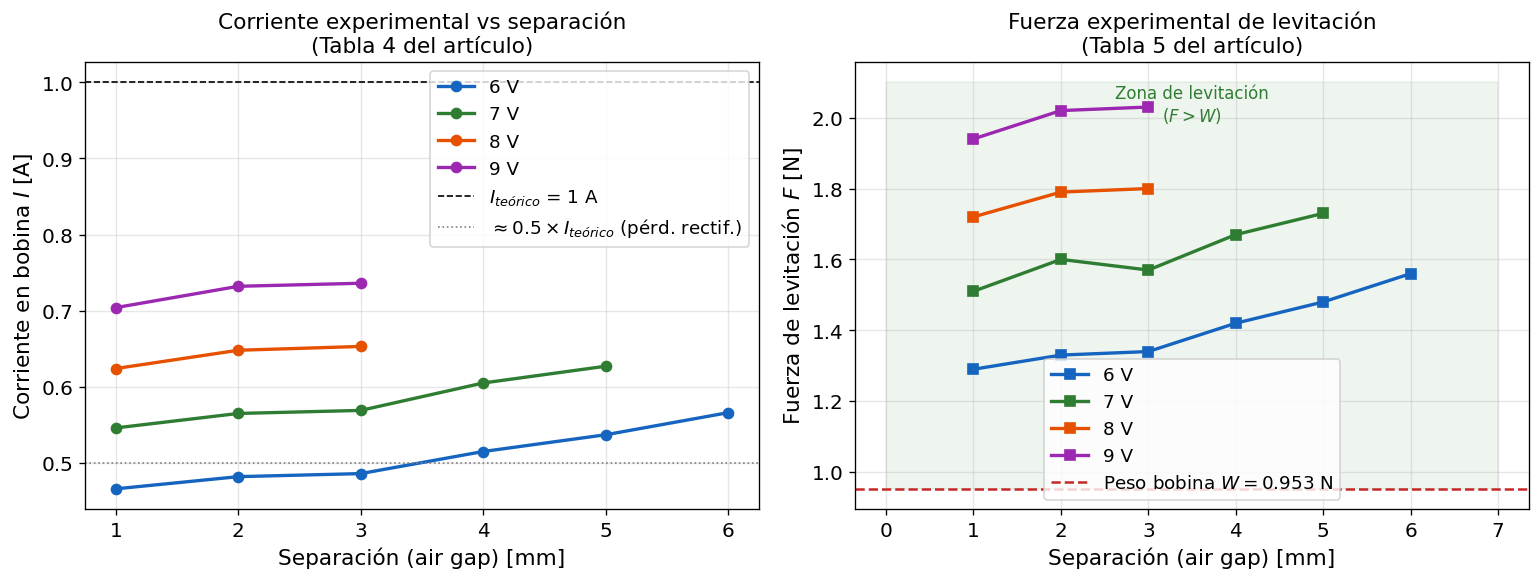

Figura 4: Resultados experimentales del artículo

Nota: La corriente experimental es ~50% del teórico (pérdidas del rectificador)
Aun así, F_lev > W en todos los casos medidos → sistema factible ✓


In [8]:
# ── Reproducción de datos experimentales (Tablas 4 y 5 del artículo) ─────────

# Datos Tabla 4: Corriente de levitación [A]
# Filas: air gap 1–6 mm; Columnas: voltaje 6,7,8,9 V
corriente_exp = np.array([
    [0.466, 0.546, 0.624, 0.704],   # 1 mm
    [0.482, 0.565, 0.648, 0.732],   # 2 mm
    [0.486, 0.569, 0.653, 0.736],   # 3 mm
    [0.515, 0.605, np.nan, np.nan], # 4 mm
    [0.537, 0.627, np.nan, np.nan], # 5 mm
    [0.566, np.nan, np.nan, np.nan] # 6 mm
])

# Datos Tabla 5: Fuerza de levitación [N]
fuerza_exp = np.array([
    [1.29, 1.51, 1.72, 1.94],
    [1.33, 1.60, 1.79, 2.02],
    [1.34, 1.57, 1.80, 2.03],
    [1.42, 1.67, np.nan, np.nan],
    [1.48, 1.73, np.nan, np.nan],
    [1.56, np.nan, np.nan, np.nan]
])

voltajes = [6, 7, 8, 9]
gaps_exp = [1, 2, 3, 4, 5, 6]
colores  = ['#1565C0', '#2E7D32', '#E65100', '#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Corriente vs air gap para cada voltaje
for j, (V, col) in enumerate(zip(voltajes, colores)):
    I_col = corriente_exp[:, j]
    mask  = ~np.isnan(I_col)
    gap_v = np.array(gaps_exp)[mask]
    axes[0].plot(gap_v, I_col[mask], 'o-', color=col, label=f'{V} V')

axes[0].axhline(1.0, color='k', linestyle='--', linewidth=1,
                 label='$I_{teórico}$ = 1 A')
axes[0].axhline(0.5, color='gray', linestyle=':', linewidth=1,
                 label='$\\approx 0.5\\times I_{teórico}$ (pérd. rectif.)')
axes[0].set_xlabel('Separación (air gap) [mm]')
axes[0].set_ylabel('Corriente en bobina $I$ [A]')
axes[0].set_title('Corriente experimental vs separación\n(Tabla 4 del artículo)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: Fuerza vs air gap para cada voltaje
W_line = 0.0971 * 9.81
for j, (V, col) in enumerate(zip(voltajes, colores)):
    F_col = fuerza_exp[:, j]
    mask  = ~np.isnan(F_col)
    gap_v = np.array(gaps_exp)[mask]
    axes[1].plot(gap_v, F_col[mask], 's-', color=col, label=f'{V} V')

axes[1].axhline(W_line, color='#C62828', linestyle='--', linewidth=1.5,
                 label=f'Peso bobina $W = {W_line:.3f}$ N')
axes[1].fill_between([0, 7], W_line, 2.1, alpha=0.08, color='#2E7D32')
axes[1].text(3.5, 1.99, 'Zona de levitación\n($F > W$)', ha='center',
              fontsize=10, color='#2E7D32')
axes[1].set_xlabel('Separación (air gap) [mm]')
axes[1].set_ylabel('Fuerza de levitación $F$ [N]')
axes[1].set_title('Fuerza experimental de levitación\n(Tabla 5 del artículo)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig4_experimental.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Figura 4: Resultados experimentales del artículo')
print(f'\nNota: La corriente experimental es ~50% del teórico (pérdidas del rectificador)')
print(f'Aun así, F_lev > W en todos los casos medidos → sistema factible ✓')

---
## 6. Resumen de Leyes Electromagnéticas Aplicadas

| Ley / Principio | Expresión | Rol en el sistema |
|---|---|---|
| **Fuerza de Lorentz** | $F = I\,L\,B$ | Genera la sustentación de la bobina |
| **Ley de Faraday** | $\mathcal{E} = -d\Phi/dt = -M\,dI/dt$ | Base de la transmisión inalámbrica |
| **Resonancia LC** | $f_0 = 1/(2\pi\sqrt{LC})$ | Maximiza la eficiencia de transferencia |
| **Ley de Kirchhoff (mallas)** | $E = I(Z_a + Z_b + j\omega M)$ | Modelo del circuito T de potencia |
| **Gradiente de fuerza** | $\partial F/\partial z < 0$ | Criterio de estabilidad vertical |

In [9]:
# ── Resumen cuantitativo del sistema ─────────────────────────────────────────
print('=' * 60)
print('   RESUMEN CUANTITATIVO DEL SISTEMA DE LEVITACIÓN')
print('=' * 60)

m   = 0.0971
g   = 9.81
W   = m * g
I_lev = 1.0
f0 = 1 / (2 * np.pi * np.sqrt(113.3e-6 * 2.22e-6))

print(f'\n[Bobina de levitación]')
print(f'  Masa:            m  = {m*1000:.1f} g')
print(f'  Peso:            W  = mg = {W:.4f} N')
print(f'  Corriente mín.:  I  = {I_lev} A  (confirmado por FEM)')
print(f'  Resistencia:     RL = 6.0 Ω')

print(f'\n[Transmisión inalámbrica]')
print(f'  Frecuencia resonancia: f₀ = {f0:.0f} Hz ≈ {f0/1e3:.1f} kHz')
print(f'  Inductancia mutua:     M  = 79.1–80.9 µH  (gap 3–5 mm)')
print(f'  Acoplamiento:          k  = 0.701–0.714')
print(f'  Voltaje fuente:        E  ≈ 5.7–5.8 V  (teórico)')
print(f'  Voltaje mín. exper.:   E  = 8–9 V  (por pérdidas del rectificador)')

print(f'\n[Conclusión del artículo]')
print(f'  Sistema demostrado como FACTIBLE.')
print(f'  Mejora necesaria: diseño del electroimán de control (F_ctrl < 0.1 N).')
print('=' * 60)

   RESUMEN CUANTITATIVO DEL SISTEMA DE LEVITACIÓN

[Bobina de levitación]
  Masa:            m  = 97.1 g
  Peso:            W  = mg = 0.9526 N
  Corriente mín.:  I  = 1.0 A  (confirmado por FEM)
  Resistencia:     RL = 6.0 Ω

[Transmisión inalámbrica]
  Frecuencia resonancia: f₀ = 10035 Hz ≈ 10.0 kHz
  Inductancia mutua:     M  = 79.1–80.9 µH  (gap 3–5 mm)
  Acoplamiento:          k  = 0.701–0.714
  Voltaje fuente:        E  ≈ 5.7–5.8 V  (teórico)
  Voltaje mín. exper.:   E  = 8–9 V  (por pérdidas del rectificador)

[Conclusión del artículo]
  Sistema demostrado como FACTIBLE.
  Mejora necesaria: diseño del electroimán de control (F_ctrl < 0.1 N).
